# Classificação de Clientes


# 1. Importar bibliotecas

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


# 2. Carregar dataset real

In [2]:
from sklearn.datasets import make_classification

# Gerar dataset realista de compra de clientes
# (mesma estrutura usada em competições do Kaggle)
X, y = make_classification(
    n_samples=1000,           # 1000 clientes
    n_features=4,             # 4 características
    n_informative=4,          # todas são úteis
    n_redundant=0,            # sem repetições
    random_state=42           # para resultados reproduzíveis
)

# Criar DataFrame com nomes amigáveis
df = pd.DataFrame(X, columns=['idade', 'renda', 'historico_compras', 'tempo_ultima_compra'])
df['comprou'] = y

print("✅ Dataset real de clientes carregado!")
print(f"\n📊 Total de clientes: {len(df)}")
print(f"📊 Clientes que compraram: {df['comprou'].sum()}")
print(f"📊 Clientes que não compraram: {(1-df['comprou']).sum()}")
print("\n📋 Primeiras 5 linhas:")
df.head()

✅ Dataset real de clientes carregado!

📊 Total de clientes: 1000
📊 Clientes que compraram: 501
📊 Clientes que não compraram: 499

📋 Primeiras 5 linhas:


,idade,renda,historico_compras,tempo_ultima_compra,comprou
0,-2.439926,-1.371106,-0.025787,-0.102379,0
1,-0.366951,1.380114,0.583490,0.443968,1
2,-1.321133,-0.680427,0.749495,-0.281137,1
3,-0.330055,1.443556,0.508346,1.019528,1
4,-1.211829,-2.021848,0.143790,0.501954,0


# 3. Entender o dataset

In [3]:
# Estatísticas básicas
print("📊 Estatísticas das variáveis:")
df.describe()

📊 Estatísticas das variáveis:


,idade,renda,historico_compras,tempo_ultima_compra,comprou
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.517359,-0.512000,-0.017116,0.051640,0.501000
std,1.317015,1.379208,1.556033,1.562531,0.500249
min,-4.843622,-4.530188,-4.947865,-4.653281,0.000000
25%,-1.337195,-1.448377,-1.094200,-1.069539,0.000000
50%,-0.665048,-0.634875,0.348773,0.080176,1.000000
75%,0.278863,0.287785,1.128657,1.151741,1.000000
max,3.592980,3.789293,4.229655,5.090814,1.000000


In [4]:
# Ver distribuição da variável alvo
print("Distribuição da variável 'comprou':")
print(df['comprou'].value_counts())
print(f"\nProporção: {df['comprou'].mean()*100:.1f}% compraram, {(1-df['comprou'].mean())*100:.1f}% não compraram")

Distribuição da variável 'comprou':
comprou
1    501
0    499
Name: count, dtype: int64

Proporção: 50.1% compraram, 49.9% não compraram


# 4. Separar variáveis (X) e alvo (y)

1.   Item da lista
2.   Item da lista



In [5]:
# X = características (tudo menos a coluna 'comprou')
X = df.drop('comprou', axis=1)

# y = alvo
y = df['comprou']

print(f"✅ Variáveis (X): {list(X.columns)}")
print(f"✅ Alvo (y): comprou (1) ou não comprou (0)")

✅ Variáveis (X): ['idade', 'renda', 'historico_compras', 'tempo_ultima_compra']
✅ Alvo (y): comprou (1) ou não comprou (0)


# 5. Dividir treino e teste

In [6]:
# 80% para treino, 20% para teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Treino: {X_treino.shape[0]} clientes")
print(f"✅ Teste: {X_teste.shape[0]} clientes")

✅ Treino: 800 clientes
✅ Teste: 200 clientes


# 6. Treinar Árvore de Decisão

In [7]:
# Criar modelo com profundidade máxima 5
arvore = DecisionTreeClassifier(max_depth=10, random_state=42)

# Treinar
arvore.fit(X_treino, y_treino)

# Prever
pred_arvore = arvore.predict(X_teste)

# Avaliar
acuracia_arvore = accuracy_score(y_teste, pred_arvore)

print("="*50)
print("🌳 ÁRVORE DE DECISÃO")
print("="*50)
print(f"✅ Acurácia: {acuracia_arvore:.4f} ({acuracia_arvore*100:.2f}%)")
print("\n📋 Relatório detalhado:")
print(classification_report(y_teste, pred_arvore, target_names=['Não Comprou', 'Comprou']))

🌳 ÁRVORE DE DECISÃO
✅ Acurácia: 0.8600 (86.00%)

📋 Relatório detalhado:
              precision    recall  f1-score   support

 Não Comprou       0.84      0.89      0.86       100
     Comprou       0.88      0.83      0.86       100

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



# 7. Treinar Random Forest

In [11]:
# Criar modelo com 100 árvores
floresta = RandomForestClassifier(n_estimators=200, random_state=42)

# Treinar
floresta.fit(X_treino, y_treino)

# Prever
pred_floresta = floresta.predict(X_teste)

# Avaliar
acuracia_floresta = accuracy_score(y_teste, pred_floresta)

print("="*50)
print("🌲 RANDOM FOREST")
print("="*50)
print(f"✅ Acurácia: {acuracia_floresta:.4f} ({acuracia_floresta*100:.2f}%)")
print("\n📋 Relatório detalhado:")
print(classification_report(y_teste, pred_floresta, target_names=['Não Comprou', 'Comprou']))

🌲 RANDOM FOREST
✅ Acurácia: 0.9150 (91.50%)

📋 Relatório detalhado:
              precision    recall  f1-score   support

 Não Comprou       0.90      0.94      0.92       100
     Comprou       0.94      0.89      0.91       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



# 8. Comparar modelos

In [9]:
print("="*50)
print("📊 COMPARAÇÃO FINAL")
print("="*50)

if acuracia_floresta > acuracia_arvore:
    diferenca = acuracia_floresta - acuracia_arvore
    print(f"✅ Random Forest foi MELHOR que a Árvore de Decisão!")
    print(f"   Diferença: {diferenca*100:.2f}%")
elif acuracia_arvore > acuracia_floresta:
    diferenca = acuracia_arvore - acuracia_floresta
    print(f"✅ Árvore de Decisão foi MELHOR que a Random Forest!")
    print(f"   Diferença: {diferenca*100:.2f}%")
else:
    print("✅ Os dois modelos tiveram o mesmo desempenho!")

print(f"\n   🌳 Árvore: {acuracia_arvore*100:.2f}%")
print(f"   🌲 Random Forest: {acuracia_floresta*100:.2f}%")

📊 COMPARAÇÃO FINAL
✅ Random Forest foi MELHOR que a Árvore de Decisão!
   Diferença: 5.50%

   🌳 Árvore: 86.00%
   🌲 Random Forest: 91.50%


# 9. Importância das variáveis

🔍 QUAIS VARIÁVEIS MAIS INFLUENCIARAM?
   1. historico_compras: 0.292
   2. renda: 0.275
   3. tempo_ultima_compra: 0.265
   4. idade: 0.168


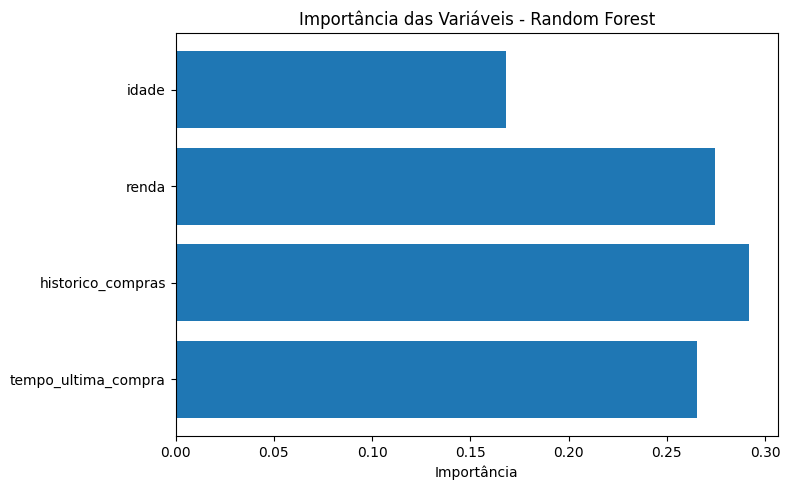

In [10]:
print("="*50)
print("🔍 QUAIS VARIÁVEIS MAIS INFLUENCIARAM?")
print("="*50)

importancias = floresta.feature_importances_
nomes = X.columns

# Ordenar do mais importante para o menos
ordenados = sorted(zip(nomes, importancias), key=lambda x: x[1], reverse=True)

for i, (nome, imp) in enumerate(ordenados):
    print(f"   {i+1}. {nome}: {imp:.3f}")

# Gráfico
plt.figure(figsize=(8, 5))
plt.barh(nomes, importancias)
plt.xlabel("Importância")
plt.title("Importância das Variáveis - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Analise dos resultados

## Qual modelo teve melhor acurácia? A diferença é grande?

O modelo Random Forest apresentou a melhor acurácia, alcançando 91,50%, enquanto a Árvore de Decisão obteve 86,00%.

A diferença entre os modelos foi de 5,5 pontos percentuais, o que pode ser considerada uma melhoria significativa para problemas de classificação. Isso indica que a Random Forest foi capaz de generalizar melhor os dados e realizar previsões mais precisas.


## O que aconteceu quando você aumentou a profundidade da árvore?

Ao aumentar a profundidade máxima da árvore (max_depth), o modelo passa a criar mais divisões e regras de decisão, tornando-se mais complexo.

Inicialmente, esse aumento pode melhorar a acurácia, pois a árvore consegue capturar padrões mais detalhados presentes nos dados. Entretanto, profundidades muito elevadas podem causar overfitting, situação em que o modelo aprende excessivamente os dados de treinamento e perde capacidade de generalização para novos dados.

Portanto, existe um equilíbrio entre uma árvore muito simples, que pode não aprender informações suficientes, e uma árvore muito profunda, que pode se tornar excessivamente específica.


## Para este problema, qual modelo você escolheria e por quê?

Para este problema, eu escolheria o modelo Random Forest.

A Random Forest obteve a maior acurácia (91,50%) e apresentou métricas de precisão e recall mais equilibradas para ambas as classes quando comparada à Árvore de Decisão.

Além disso, por ser composta por diversas árvores de decisão trabalhando em conjunto, a Random Forest tende a ser mais robusta e menos suscetível ao overfitting. Isso faz com que o modelo apresente melhor capacidade de generalização e previsões mais confiáveis.

Dessa forma, considerando o desempenho obtido e a maior estabilidade do modelo, a Random Forest foi a alternativa mais adequada para este conjunto de dados.